In [ ]:
!pip -q install biopython

from Bio.Seq import Seq
from Bio.Restriction import RestrictionBatch, AllEnzymes
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.5 MB/s eta 0:00:00


In [ ]:
uploaded = files.upload()
file = next(iter(uploaded))

with open(file) as f:
    lines = f.readlines()

header = lines[0].strip()
seq = ''.join(x.strip() for x in lines[1:]).upper()

print("Sequence:", header)
print("Length:", len(seq), "bp")

print("\nCOMPLETE NUCLEOTIDE SEQUENCE:\n")
for i in range(0, len(seq), 60):
    print(f"{i+1:5d}  {seq[i:i+60]}")

Saving sequence.fasta to sequence.fasta
Sequence: >NM_001101.5 Homo sapiens actin beta (ACTB), mRNA
Length: 1812 bp

COMPLETE NUCLEOTIDE SEQUENCE:

    1  ACCGCCGAGACCGCGTCCGCCCCGCGAGCACAGAGCCTCGCCTTTGCCGATCCGCCGCCC
   61  GTCCACACCCGCCGCCAGCTCACCATGGATGATGATATCGCCGCGCTCGTCGTCGACAAC
  121  GGCTCCGGCATGTGCAAGGCCGGCTTCGCGGGCGACGATGCCCCCCGGGCCGTCTTCCCC
  181  TCCATCGTGGGGCGCCCCAGGCACCAGGGCGTGATGGTGGGCATGGGTCAGAAGGATTCC
  241  TATGTGGGCGACGAGGCCCAGAGCAAGAGAGGCATCCTCACCCTGAAGTACCCCATCGAG
  301  CACGGCATCGTCACCAACTGGGACGACATGGAGAAAATCTGGCACCACACCTTCTACAAT
  361  GAGCTGCGTGTGGCTCCCGAGGAGCACCCCGTGCTGCTGACCGAGGCCCCCCTGAACCCC
  421  AAGGCCAACCGCGAGAAGATGACCCAGATCATGTTTGAGACCTTCAACACCCCAGCCATG
  481  TACGTTGCTATCCAGGCTGTGCTATCCCTGTACGCCTCTGGCCGTACCACTGGCATCGTG
  541  ATGGACTCCGGTGACGGGGTCACCCACACTGTGCCCATCTACGAGGGGTATGCCCTCCCC
  601  CATGCCATCCTGCGTCTGGACCTGGCTGGCCGGGACCTGACTGACTACCTCATGAAGATC
  661  CTCACCGAGCGCGGCTACAGCTTCACCACCACGGCCGAGCGGGAAATCGTGCGTGACATT
  721  AAGGAGAAGCTGTGCTACGTCGCCCTGGA

In [ ]:
dna = Seq(seq)
results = RestrictionBatch(AllEnzymes).search(dna)

sites = {
    str(e): list(p)
    for e, p in results.items()
    if len(p) > 0
}

print("\nRESTRICTION SITES")
print("-" * 70)

for e, p in sites.items():
    print(f"{e:12}  sites = {len(p):3}   positions = {p}")


RESTRICTION SITES
----------------------------------------------------------------------
SapI          sites =   1   positions = [791]
MmeI          sites =   1   positions = [1368]
BseSI         sites =   3   positions = [576, 1675, 1799]
PspGI         sites =  13   positions = [197, 204, 492, 621, 744, 789, 819, 882, 1003, 1041, 1119, 1730, 1751]
Eco1836I      sites =   1   positions = [934]
Lmo911II      sites =   2   positions = [351, 1206]
BseXI         sites =   6   positions = [351, 381, 760, 795, 839, 1760]
PciSI         sites =   1   positions = [791]
BcgI          sites =   4   positions = [572, 606, 1567, 1601]
Bau1417V      sites =   1   positions = [412]
Cre7908I      sites =   1   positions = [699]
Pst145I       sites =   3   positions = [579, 801, 1505]
BspACI        sites =  20   positions = [3, 12, 18, 23, 53, 56, 70, 73, 102, 149, 430, 672, 700, 844, 850, 952, 987, 1110, 1198, 1214]
Eco31I        sites =   4   positions = [2, 452, 1731, 1771]
BpuMI         sites =   

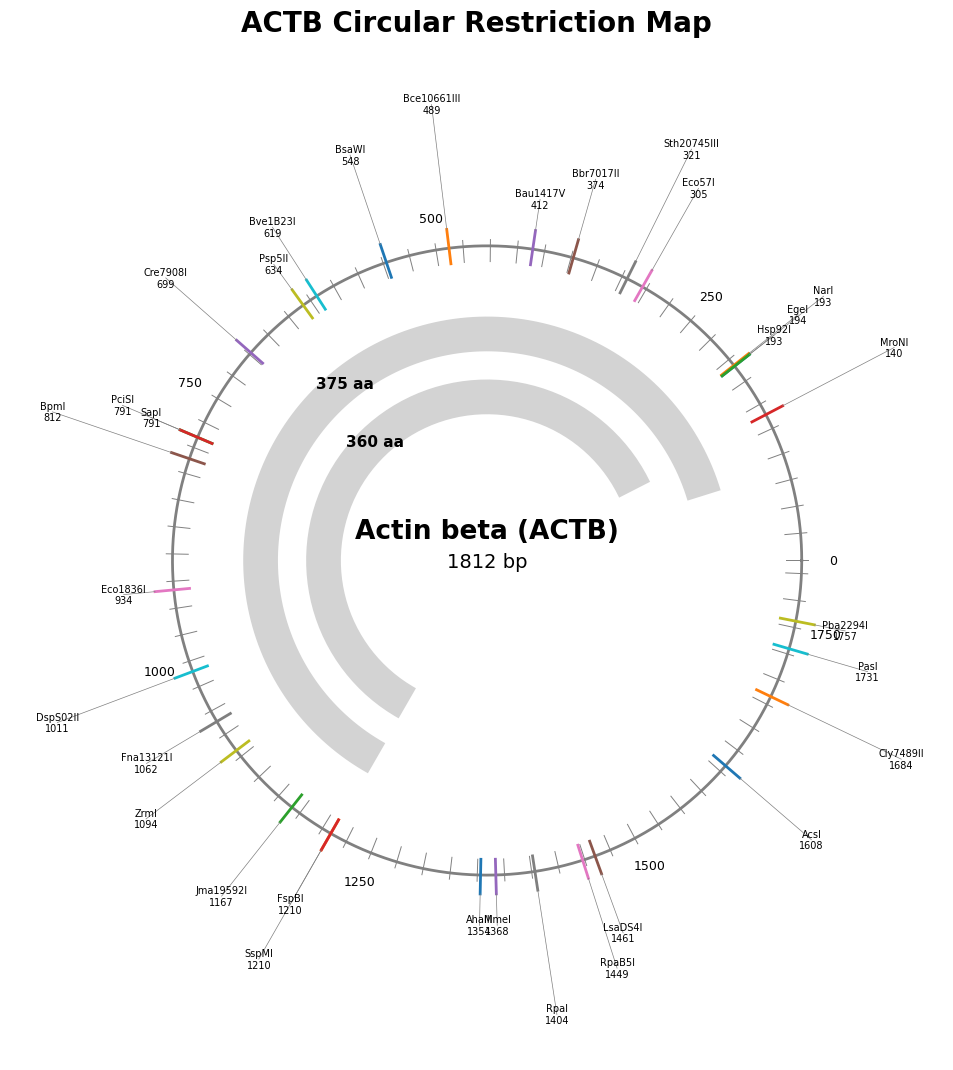

In [ ]:


import matplotlib.pyplot as plt
import numpy as np

N = len(seq)



all_sites = [
    (str(e), list(p))
    for e, p in results.items()
    if len(p) > 0
]


regions = [(i*N//8, (i+1)*N//8) for i in range(8)]

selected = []

for start, end in regions:

    candidates = []

    for enzyme, positions in all_sites:


        if any(start <= p <= end for p in positions):
            candidates.append((enzyme, positions))


    candidates.sort(key=lambda x: len(x[1]))


    selected.extend(candidates[:4])


unique = {}

for enzyme, positions in selected:
    unique[enzyme] = positions

selected = list(unique.items())




fig, ax = plt.subplots(figsize=(13, 13))
ax.set_aspect("equal")
ax.axis("off")

theta = np.linspace(0, 2*np.pi, 500)

ax.plot(
    np.cos(theta),
    np.sin(theta),
    color="gray",
    linewidth=2
)


for pos in range(0, N, 25):

    a = 2*np.pi*pos/N

    ax.plot(
        [0.95*np.cos(a), 1.02*np.cos(a)],
        [0.95*np.sin(a), 1.02*np.sin(a)],
        color="gray",
        linewidth=0.7
    )

for pos in range(0, N, 250):

    a = 2*np.pi*pos/N

    ax.text(
        1.10*np.cos(a),
        1.10*np.sin(a),
        str(pos),
        fontsize=9,
        ha="center",
        va="center"
    )



for i, (enzyme, positions) in enumerate(selected):

    for pos in positions:

        a = 2*np.pi*(pos-1)/N


        ax.plot(
            [0.95*np.cos(a), 1.06*np.cos(a)],
            [0.95*np.sin(a), 1.06*np.sin(a)],
            linewidth=2
        )


        level = i % 4
        r = 1.16 + level*0.10

        lx = r*np.cos(a)
        ly = r*np.sin(a)


        ax.plot(
            [1.06*np.cos(a), lx],
            [1.06*np.sin(a), ly],
            color="gray",
            linewidth=0.5
        )

        ax.text(
            lx,
            ly,
            f"{enzyme}\n{pos}",
            fontsize=7,
            ha="center",
            va="center"
        )



stop_codons = {"TAA", "TAG", "TGA"}
orfs = []

for frame in range(3):

    for start in range(frame, N-2, 3):

        if seq[start:start+3] == "ATG":

            for end in range(start+3, N-2, 3):

                if seq[end:end+3] in stop_codons:

                    aa = (end-start)//3

                    if aa >= 50:
                        orfs.append((start, end+3, aa))

                    break


orfs.sort(key=lambda x: x[2], reverse=True)




for k, (start, end, aa) in enumerate(orfs[:2]):

    radius = 0.72 - k*0.20

    a1 = 2*np.pi*start/N
    a2 = 2*np.pi*end/N

    angles = np.linspace(a1, a2, 150)


    ax.plot(
        radius*np.cos(angles),
        radius*np.sin(angles),
        color="lightgray",
        linewidth=25,
        solid_capstyle="butt"
    )


    ax.annotate(
        "",
        xy=(radius*np.cos(a2),
            radius*np.sin(a2)),
        xytext=(
            radius*np.cos(a2-0.10),
            radius*np.sin(a2-0.10)
        ),
        arrowprops=dict(
            arrowstyle="-|>",
            color="lightgray",
            lw=9
        )
    )


    mid = (a1+a2)/2

    ax.text(
        radius*np.cos(mid),
        radius*np.sin(mid),
        f"{aa} aa",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center"
    )




ax.text(
    0, 0.07,
    "Actin beta (ACTB)",
    fontsize=19,
    fontweight="bold",
    ha="center"
)

ax.text(
    0, -0.02,
    f"{N} bp",
    fontsize=14,
    ha="center"
)


ax.set_title(
    "ACTB Circular Restriction Map",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.show()

In [ ]:

from IPython.display import display, HTML


colors = {
    "Blunt-End Cut": "#2196F3",
    "Cuts 1 strand": "#4CAF50",
    "5′ Extension": "#FF9800",
    "3′ Extension": "#F44336"
}

table_rows = []

for enzyme, positions in selected:


    enzyme_obj = next(
        (e for e in results.keys() if str(e) == enzyme),
        None
    )

    if enzyme_obj is None:
        continue


    recognition = getattr(enzyme_obj, "site", "N/A")


    try:

        if enzyme_obj.is_blunt():
            cleavage = "Blunt-End Cut"

        elif hasattr(enzyme_obj, "is_nicking") and enzyme_obj.is_nicking():
            cleavage = "Cuts 1 strand"

        elif enzyme_obj.is_5overhang():
            cleavage = "5′ Extension"

        elif enzyme_obj.is_3overhang():
            cleavage = "3′ Extension"

        else:
            cleavage = "Other"

    except:
        cleavage = "Other"

    color = colors.get(cleavage, "#777777")


    for position in positions:

        table_rows.append(f"""
        <tr>
            <td>{enzyme}</td>
            <td>{recognition}</td>
            <td>{position}</td>

            <td>
                <span style="
                background-color:{color};
                color:white;
                padding:5px 10px;
                border-radius:5px;
                font-weight:bold;">
                {cleavage}
                </span>
            </td>
        </tr>
        """)


html = """
<h2>ACTB Restriction Enzyme Cleavage Information</h2>

<table style="
border-collapse:collapse;
width:100%;
font-family:Arial;
font-size:14px;">

<tr style="background-color:#eeeeee;">
    <th style="padding:10px;border:1px solid #aaa;">
        Enzyme
    </th>

    <th style="padding:10px;border:1px solid #aaa;">
        Recognition Site
    </th>

    <th style="padding:10px;border:1px solid #aaa;">
        Position (bp)
    </th>

    <th style="padding:10px;border:1px solid #aaa;">
        Cleavage
    </th>
</tr>

""" + "".join(table_rows) + """

</table>
"""

display(HTML(html))

Enzyme,Recognition Site,Position (bp),Cleavage
Hsp92I,GRCGYC,193,5′ Extension
EgeI,GGCGCC,194,Blunt-End Cut
NarI,GGCGCC,193,5′ Extension
MroNI,GCCGGC,140,5′ Extension
Bau1417V,GTTCAG,412,Other
Bbr7017II,CGGGAG,374,Other
Eco57I,CTGAAG,305,3′ Extension
Sth20745III,GGACGAC,321,Other
Psp5II,RGGWCCY,634,5′ Extension
Bve1B23I,GACNNNNNTGG,619,Other
